In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

arquivo = Path('vendas.csv')

if not arquivo.exists():
    rng = np.random.default_rng(42)
    datas = pd.date_range('2024-01-01', '2024-12-31', periods=240)
    lojas = ['Norte', 'Sul', 'Leste', 'Oeste']
    regioes = {'Norte': 'Norte', 'Sul': 'Sul', 'Leste': 'Centro-Oeste', 'Oeste': 'Sudeste'}
    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Impressora', 'Teclado', 'Mouse', 'Headset']
    df = pd.DataFrame({
        'data': rng.choice(datas, size=240, replace=True),
        'loja': rng.choice(lojas, size=240),
        'regiao': rng.choice(list(regioes.keys()), size=240),
        'produto': rng.choice(produtos, size=240),
        'quantidade': rng.integers(1, 9, size=240),
        'preco_unitario': np.round(rng.uniform(50, 2200, size=240), 2)
    })
    df['regiao'] = df['loja'].map(regioes)
    indices_quantidade = rng.integers(0, len(df), size=8)
    indices_preco = rng.integers(0, len(df), size=6)
    df.loc[indices_quantidade, 'quantidade'] = np.nan
    df.loc[indices_preco, 'preco_unitario'] = np.nan
    df.to_csv(arquivo, index=False)

print(f'Arquivo criado: {arquivo}')

Arquivo criado: vendas.csv


In [10]:
df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'])
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df.head()

,data,loja,regiao,produto,quantidade,preco_unitario,faturamento
0,2024-02-02 01:42:25.606694,Norte,Norte,Smartphone,2.0,1076.64,2153.28
1,2024-10-09 12:45:11.297071,Leste,Centro-Oeste,Headset,4.0,1687.08,6748.32
2,2024-08-27 18:28:37.154811,Norte,Norte,Mouse,NaN,1992.15,NaN
3,2024-06-09 08:32:08.033472,Leste,Centro-Oeste,Notebook,2.0,1599.50,3199.00
4,2024-06-06 07:13:48.451882,Leste,Centro-Oeste,Mouse,8.0,2120.90,16967.20


In [11]:
df.info()
print('\nValores ausentes por coluna:')
print(df.isnull().sum())
print('\nResumo estatístico:')
print(df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            240 non-null    datetime64[us]
 1   loja            240 non-null    str           
 2   regiao          240 non-null    str           
 3   produto         240 non-null    str           
 4   quantidade      232 non-null    float64       
 5   preco_unitario  234 non-null    float64       
 6   faturamento     226 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 13.3 KB

Valores ausentes por coluna:
data               0
loja               0
regiao             0
produto            0
quantidade         8
preco_unitario     6
faturamento       14
dtype: int64

Resumo estatístico:
                count unique       top freq                        mean  \
data              240    NaN       NaN  NaN  2024-07-05 07:56:14.058577   
loja      

In [12]:
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].median())
df['preco_unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].median())
df['faturamento'] = df['quantidade'] * df['preco_unitario']

print('Valores ausentes após tratamento:')
print(df.isnull().sum())

Valores ausentes após tratamento:
data              0
loja              0
regiao            0
produto           0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64


In [13]:
faturamento_loja = df.groupby('loja', as_index=False)['faturamento'].sum().sort_values('faturamento', ascending=False)
faturamento_loja

,loja,faturamento
1,Norte,336060.71
2,Oeste,320130.25
3,Sul,284755.34
0,Leste,279574.31


In [14]:
total_vendas = df.shape[0]
ticket_medio = df['faturamento'].sum() / total_vendas
print(f'Ticket médio: R$ {ticket_medio:,.2f}')

produtos_mais_vendidos = df.groupby('produto', as_index=False)['quantidade'].sum().sort_values('quantidade', ascending=False).head()
produtos_mais_vendidos

Ticket médio: R$ 5,085.50


,produto,quantidade
4,Notebook,178.0
0,Headset,156.0
7,Teclado,149.0
2,Monitor,145.0
3,Mouse,134.0


In [15]:
df['mes'] = df['data'].dt.to_period('M').astype(str)
faturamento_mensal = df.groupby('mes', as_index=False)['faturamento'].sum().sort_values('faturamento', ascending=False)

mes_maior = faturamento_mensal.iloc[0]
mes_menor = faturamento_mensal.iloc[-1]

print(f"Mês com maior faturamento: {mes_maior['mes']} -> R$ {mes_maior['faturamento']:,.2f}")
print(f"Mês com menor faturamento: {mes_menor['mes']} -> R$ {mes_menor['faturamento']:,.2f}")
faturamento_mensal.head()

Mês com maior faturamento: 2024-06 -> R$ 216,857.86
Mês com menor faturamento: 2024-12 -> R$ 48,601.68


,mes,faturamento
5,2024-06,216857.86
9,2024-10,176198.83
3,2024-04,124508.78
8,2024-09,108310.84
1,2024-02,93092.06


C:\Users\faely\AppData\Local\Temp\ipykernel_21472\1774504871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_loja, x='faturamento', y='loja', palette='viridis', order=faturamento_loja.sort_values('faturamento', ascending=False)['loja'])


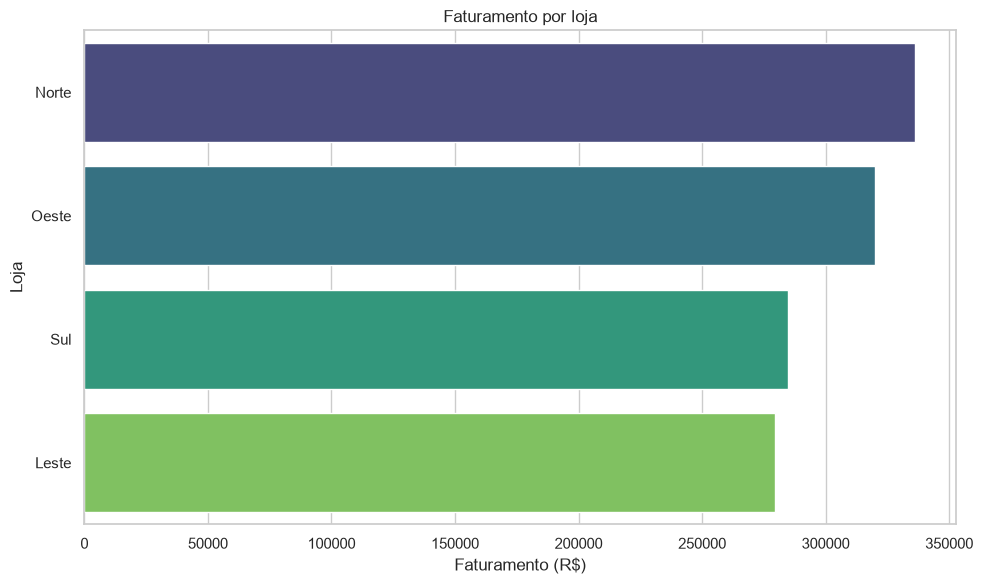

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=faturamento_loja, x='faturamento', y='loja', palette='viridis', order=faturamento_loja.sort_values('faturamento', ascending=False)['loja'])
plt.title('Faturamento por loja')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Loja')
plt.tight_layout()
plt.savefig('grafico_barras_loja.png', dpi=300)
plt.show()

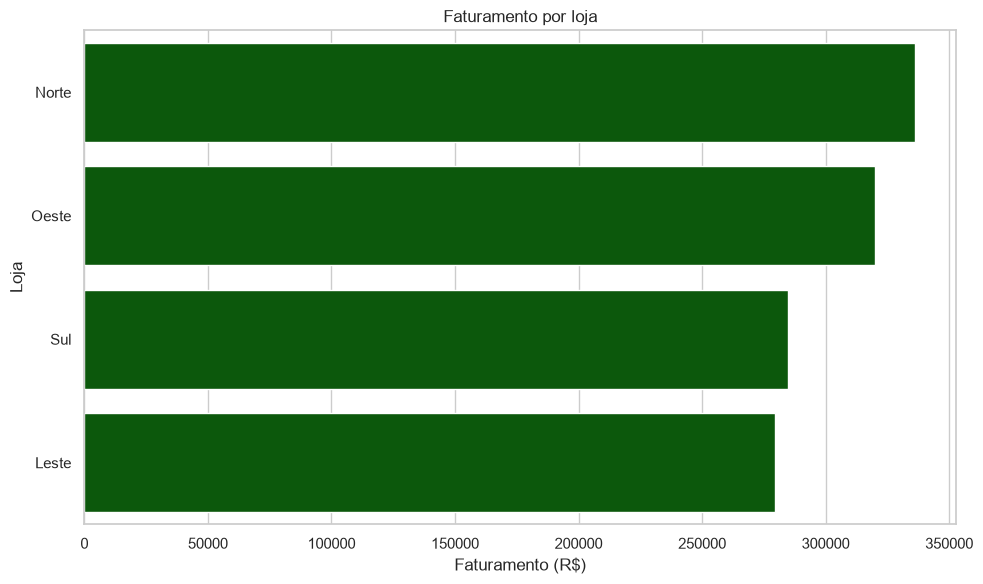

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=faturamento_loja, x='faturamento', y='loja', color='darkgreen', order=faturamento_loja.sort_values('faturamento', ascending=False)['loja'])
plt.title('Faturamento por loja')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Loja')
plt.tight_layout()
plt.savefig('grafico_barras_loja.png', dpi=300)
plt.show()

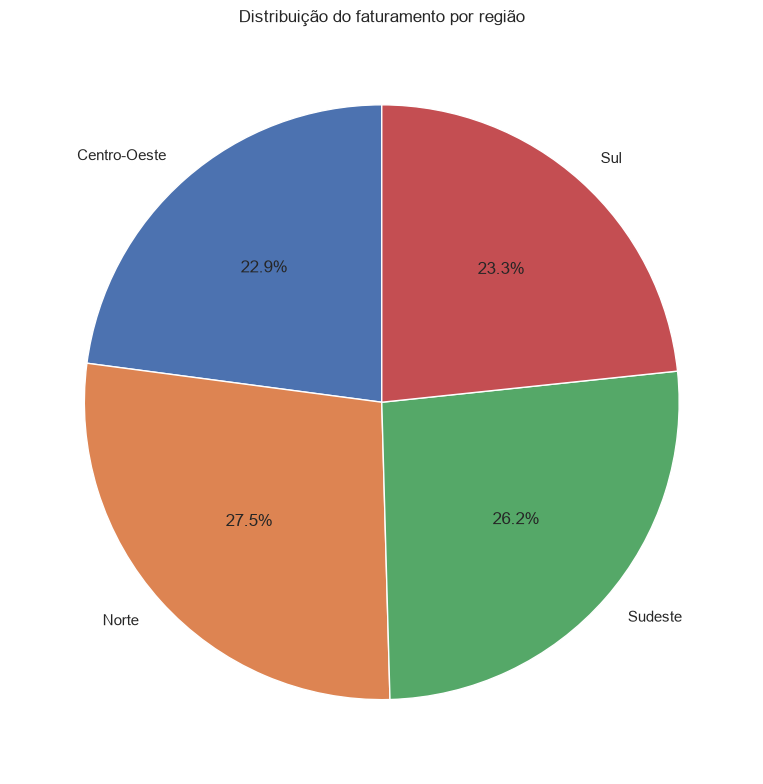

In [18]:
faturamento_regiao = df.groupby('regiao', as_index=False)['faturamento'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    faturamento_regiao['faturamento'],
    labels=faturamento_regiao['regiao'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Distribuição do faturamento por região')
plt.tight_layout()
plt.savefig('grafico_pizza_regiao.png', dpi=300)
plt.show()

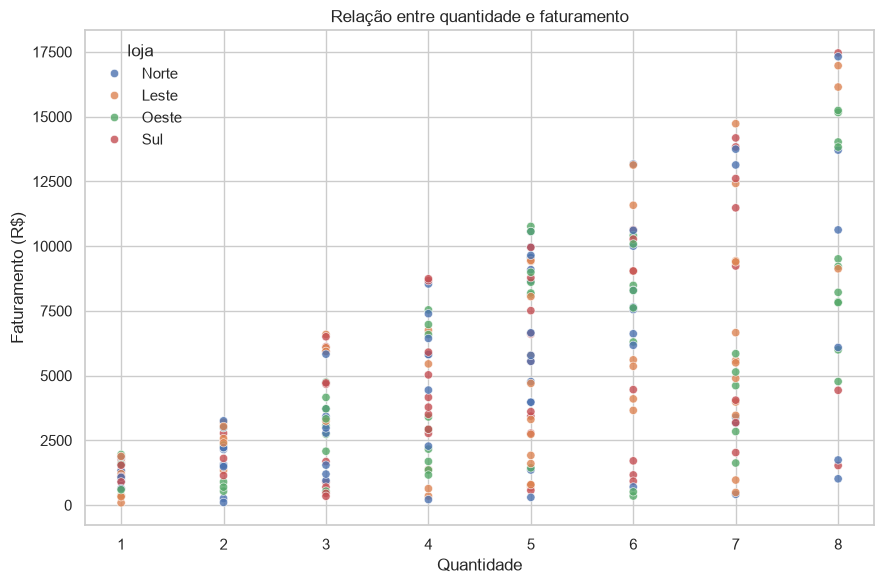

In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='loja', alpha=0.8)
plt.title('Relação entre quantidade e faturamento')
plt.xlabel('Quantidade')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('grafico_dispersao_quantidade_faturamento.png', dpi=300)
plt.show()

C:\Users\faely\AppData\Local\Temp\ipykernel_21472\825603942.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='regiao', y='faturamento', palette='Set2')


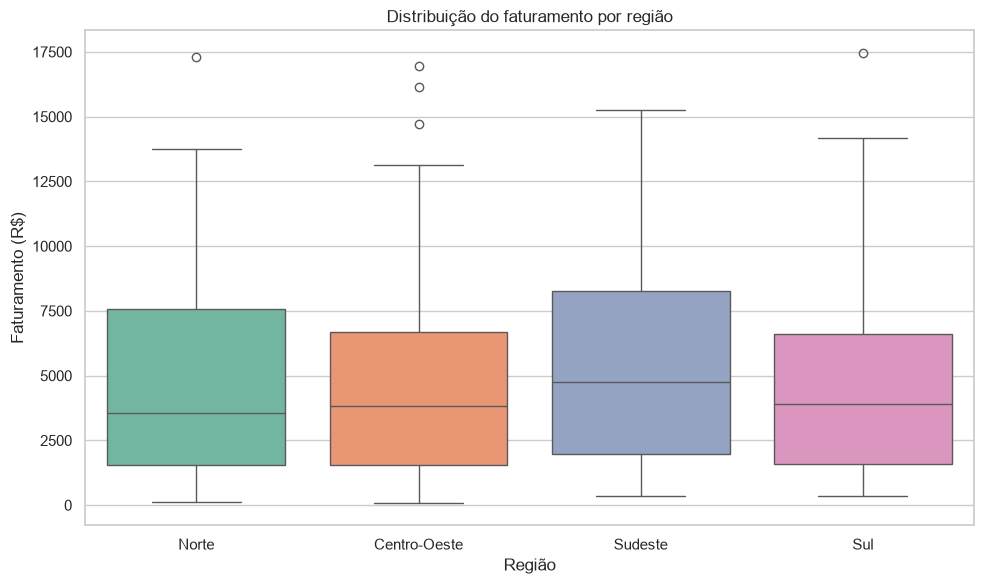

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='regiao', y='faturamento', palette='Set2')
plt.title('Distribuição do faturamento por região')
plt.xlabel('Região')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('boxplot_faturamento_regiao.png', dpi=300)
plt.show()

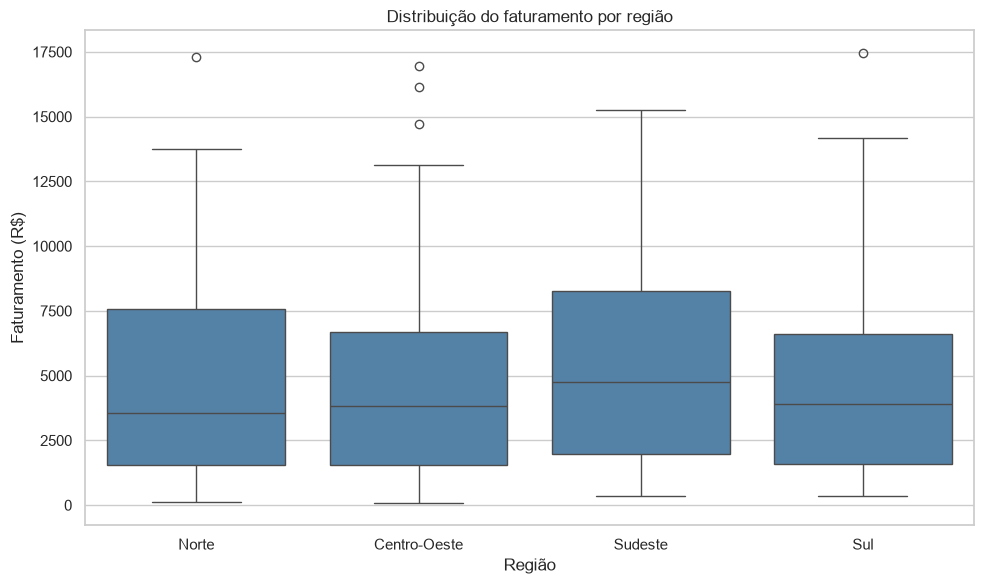

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='regiao', y='faturamento', color='steelblue')
plt.title('Distribuição do faturamento por região')
plt.xlabel('Região')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('boxplot_faturamento_regiao.png', dpi=300)
plt.show()

In [22]:
sns.set_context('talk')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Gráficos salvos na pasta atual:')
for nome in [
    'grafico_barras_loja.png',
    'grafico_linha_mensal.png',
    'grafico_pizza_regiao.png',
    'grafico_dispersao_quantidade_faturamento.png',
    'boxplot_faturamento_regiao.png',
    'heatmap_correlacao.png'
]:
    print('-', nome)

Gráficos salvos na pasta atual:
- grafico_barras_loja.png
- grafico_linha_mensal.png
- grafico_pizza_regiao.png
- grafico_dispersao_quantidade_faturamento.png
- boxplot_faturamento_regiao.png
- heatmap_correlacao.png
